# Useful Functions

In [1]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):

    # Set the size of the plot
    plt.figure(figsize=(10,4))

    # Plot train, test and predictions
    plt.plot(train, label='Train')
    plt.plot(test, label='Test')
    plt.plot(predictions, label='Forecast')

    # Title and legend
    plt.title(f"Train, Test and Predictions with {chart_title}")
    plt.legend()
    plt.show()

    # Metrics
    mae = mean_absolute_error(test, predictions)

    # RMSE
    rmse = np.sqrt(mean_squared_error(test, predictions))

    # MAPE
    mape = mean_absolute_percentage_error(test, predictions)

    # Print metrics
    print(f"The MAE is {mae:.2f}")
    print(f"The RMSE is {rmse:.2f}")
    print(f"The MAPE is {100 * mape:.2f} %")

In [2]:
# Function to plot the future
def plot_future(y, forecast, title):
  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))
  # Plot the train and forecast data
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")
  # add title and legend to the plot
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

# Libraries and Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/EAFIT/SIMAT/Metro/data/

/content/drive/MyDrive/EAFIT/SIMAT/Metro/data


In [7]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from pmdarima import auto_arima, ARIMA, model_selection
import numpy as np
from sklearn.model_selection import ParameterGrid

In [8]:
# Loading the daily revenue data and set the date as uindex

df_raw = pd.read_csv("serie_tiempo_envigado.csv")

df_raw["Datetime"] = pd.to_datetime(df_raw["Datetime"])

df_raw = df_raw.set_index("Datetime")

In [9]:
# Set the dataframe to have daily frequency
df = df_raw.resample("D").sum()

In [10]:
# Change the time Series variable name
df = df.rename(columns = {'Consumo': 'y'})

# Exploratory Data Analysis

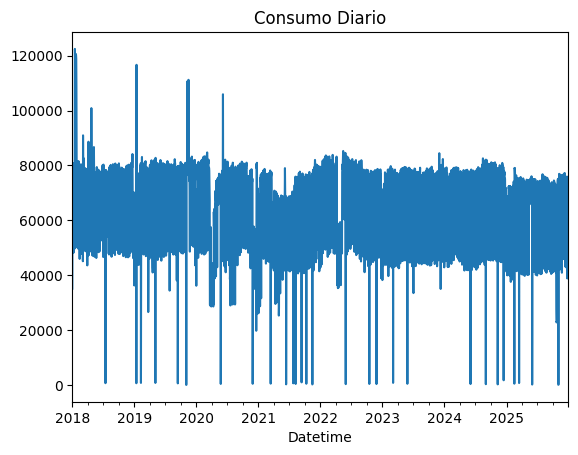

In [11]:
# Daily revenues line plot
df['y'].plot(title = 'Consumo Diario')
plt.show()

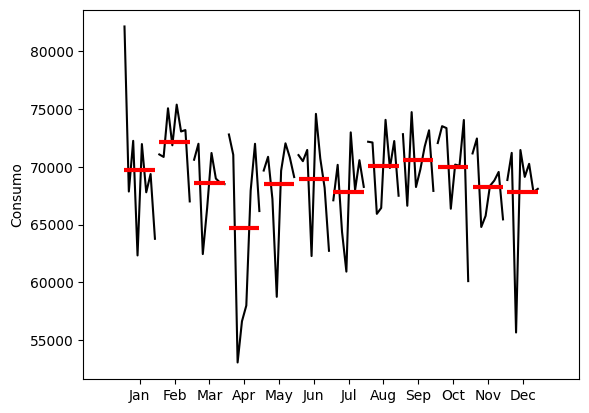

In [12]:
# month_plot() - To visualize the average value for each month across multiple years in a time series
# red lines - Represents the mean value for each month

# Plotting the monthly seasonality of revenue values
month_plot(df['y'].resample('ME').mean(),
           ylabel = 'Consumo')
plt.show()

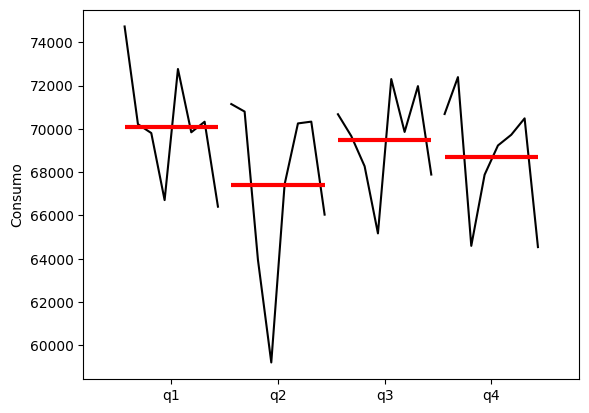

In [14]:
# quarter_plot() - To visualize seasonal patterns at a quarterly level.
# Q1 (january, february, march), Q2 (april, may, june), Q3 (july, august, september), Q4 (october, november, december)

# Plotting the quarterly seasonality of revenue values
# .resample('Q') - to convert the time series data into quarterly seasonality
quarter_plot(df['y'].resample('QE').mean(),
           ylabel = 'Consumo')
plt.show()

`seasonal_decompose` - To decompose a time series into its constituent parts to better understand the underlying patterns.

components

- Trend: The overall direction of the series (increasing, decreasing, or stable).
- Seasonal: Repeating patterns at fixed intervals (e.g., daily, weekly, monthly).
- Residual: The remaining variation after removing trend and seasonal components.

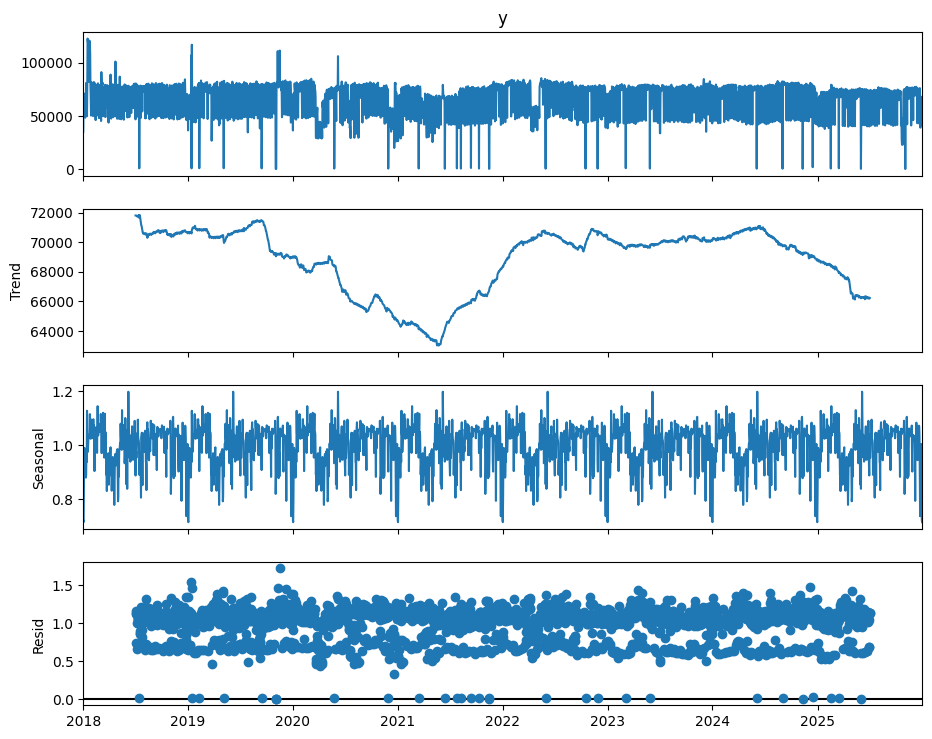

In [15]:
# Seasonal Decomposition Plots for Revenue Data
# Multiplicative model type, with daily seasonality (365 days)
decomposition = df.copy()
decomposition[decomposition["y"] == 0] = 0.0000001
decomposition = seasonal_decompose(decomposition['y'],
                                   model = 'mul',
                                   period = 365)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

Autocorrelation measures the correlation between a time series and a lagged version of itself.

Purpose: To identify patterns or repeating cycles in a time series dataset.

Interpretation:
- Values range from -1 to 1.
- 1 indicates perfect positive correlation.
- -1 indicates perfect negative correlation.
- 0 indicates no correlation.

ACF Plot:
- X-axis: Lag periods
- Y-axis: Correlation coefficient

Key Features:
- At lag 0, autocorrelation is always 1 (a series is perfectly correlated with itself).
- Significant spikes at certain lags indicate repeating patterns.


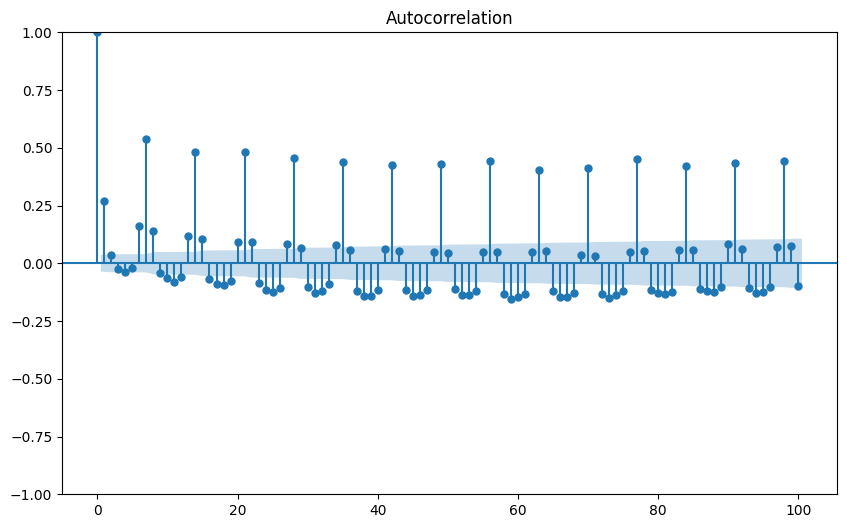

In [16]:
# Plot the autocorrelation (ACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df['y'], lags = 100, ax = ax)
plt.show()

PACF measures the correlation between a time series and its lag, after removing the effects of all shorter lags.

Purpose: To identify the direct relationship between an observation and its lag, without intermediate effects.

Main Difference between ACF and PACF:
- ACF: Measures overall correlation at each lag, including indirect effects.
- PACF: Measures direct correlation at each lag, excluding indirect effects.

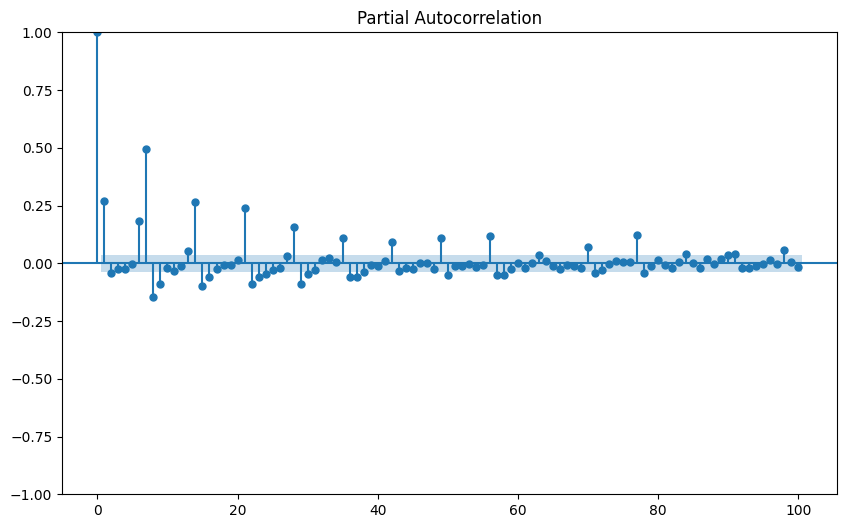

In [17]:
# Plot the partial autocorrelation (PACF) of revenue values
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df['y'], lags = 100, ax = ax)
plt.show()

`.resample()` offset aliases:
- B = business day
- D = calendar day
- W = weekly
- M = month end
- BM = business month end
- MS = month start
- BMS = business month start
- Q = quarter end
- BQ = business quarter end
- QS = quarter start
- BQS = business quarter start
- A = year end
- BA = business year end
- AS = year start
- BAS = business year start
- h = hourly
- min = minutely
- s = secondly
- ms = milliseconds
- us = microseconds

# Stationarity

`adfuller` - used to perform the Augmented Dickey-Fuller test, which is a statistical test for testing the stationarity of a time series

 Stationarity implies that the statistical properties of the time series, such as mean and variance, do not change over time.

 The test evaluates a null hypothesis that the time series is non-stationary. If the p-value obtained from the test is less than a significance level (commonly 0.05), we reject the null hypothesis and conclude that the time series is stationary.

In [18]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
# 'result' contains the test statistic and the p-value.
result = adfuller(df.y)
print('p-value: %f' % result[1])

# Interpreting the results
if result[1] < 0.05:
    print("Evidence suggests that the time series is stationary.")
else:
    print("Evidence suggests that the time series is not stationary.")


p-value: 0.000000
Evidence suggests that the time series is stationary.


In [19]:
# Compute the first difference of the 'y' column in DataFrame 'df' and assign it to a new column 'y_diff'.
# '.diff()' calculates the difference between consecutive elements along the specified axis (by default axis 0).
# 'dropna()' removes any rows with NaN values resulting from differencing.
df['y_diff'] = df['y'].diff()
df = df.dropna()

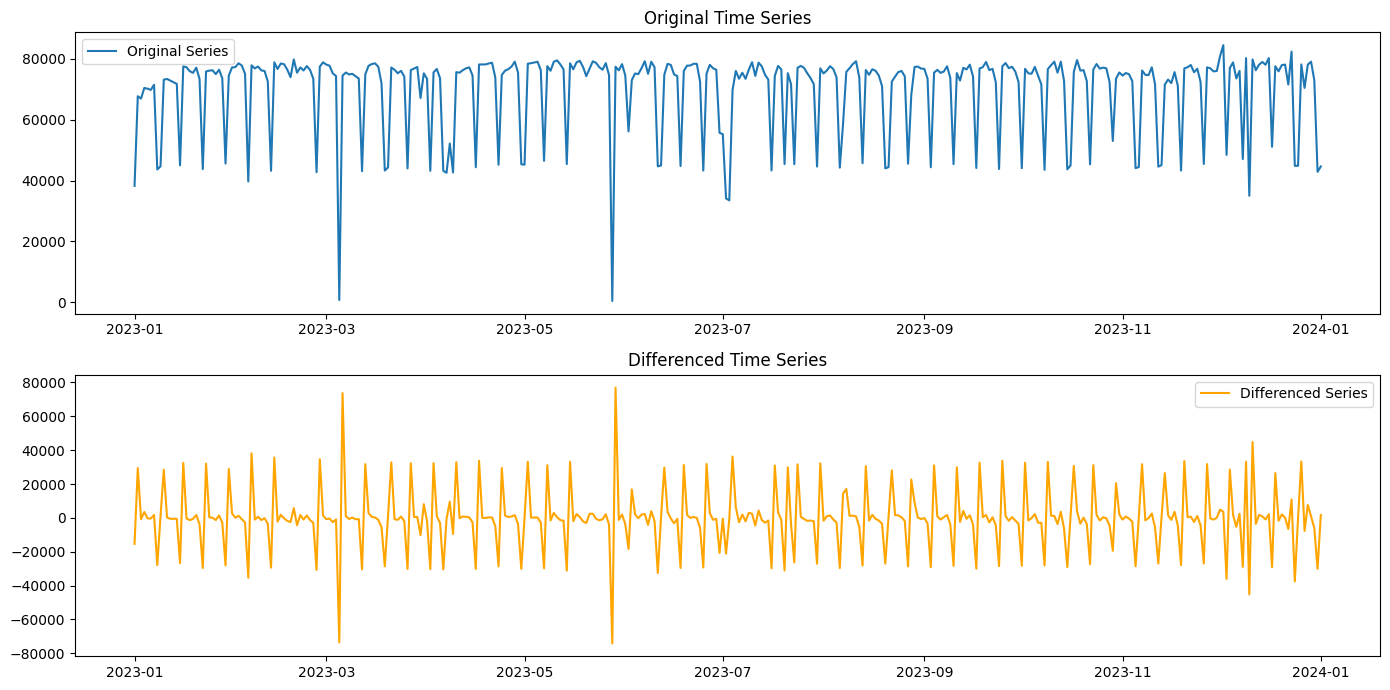

In [20]:
# Plotting the original and differenced series
# Set the size of the plot to 14 inches by 7 inches
plt.figure(figsize=(14, 7))

B_YEAR = "2023"
F_YEAR = "2024"

WHERE = (df.index >= B_YEAR) & (df.index <= F_YEAR)

# Subplot for the original series
plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
plt.plot(df['y'][WHERE], label='Original Series')
plt.title('Original Time Series')
plt.legend()

# Subplot for the differenced series
plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
plt.plot(df['y_diff'][WHERE], label='Differenced Series', color='orange')
plt.title('Differenced Time Series')
plt.legend()

# Adjust layout to prevent overlapping of titles and labels
plt.tight_layout()
plt.show()

In [21]:
# Perform ADF test without null values
# 'result' contains the test statistic and the p-value.
result = adfuller(df['y_diff'].dropna())
print('p-value: %f' % result[1])

# Interpreting the results
if result[1] < 0.05:
    print("Evidence suggests that the time series is stationary.")
else:
    print("Evidence suggests that the time series is not stationary.")

p-value: 0.000000
Evidence suggests that the time series is stationary.


# ARIMA Model

In [24]:
# Split the Data into training and test
test_days = 30 # Number of days to reserve for testing
train, test = df.iloc[:-test_days], df.iloc[-test_days:]

In [25]:
# auto_arima() from pmdarima - used to automatically select the optimal parameters for an ARIMA model based on the provided time series data.
# 'seasonal=False' indicates that the model should not consider seasonal components.
model = auto_arima(train['y'],
                   seasonal = False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2891
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -31813.693
Date:                Fri, 15 May 2026   AIC                          63635.386
Time:                        14:32:26   BIC                          63659.263
Sample:                    01-02-2018   HQIC                         63643.991
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0622      0.087      0.716      0.474      -0.108       0.232
ma.L1         -0.7913      0.089     -8.918      0.000      -0.965      -0.617
ma.L2         -0.1885      0.086     -2.184      0.029      -0.358      -0.019
sigma2      2.232e+08   3.29e-10   6.78e+17      0.000    2.23e+08    2.23e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              3332.19
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -1.59
Prob(H) (two-sided):                  0.09   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.15e+34. Standard errors may be unstable.
"""

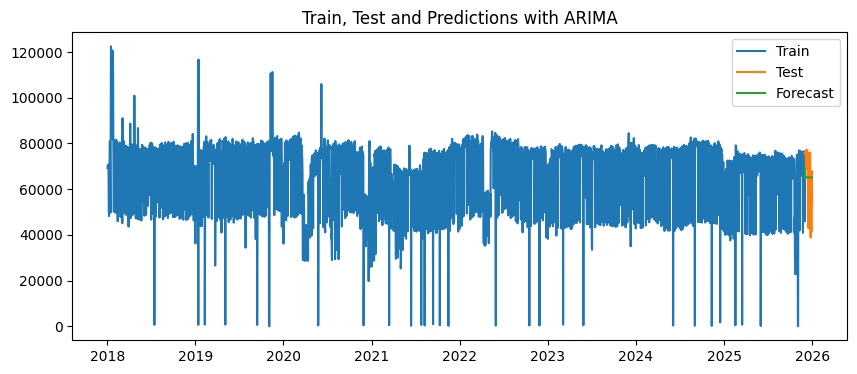

The MAE is 9786.16
The RMSE is 11824.35
The MAPE is 16.73 %


In [26]:
# Use the fitted ARIMA model to forecast future values.
# set the number of periods to forecast to the length of 'test'
predictions_arima = model.predict(n_periods = len(test))

predictions_arima = pd.Series(
    predictions_arima,
    index=test.index
)

# Model assessment
model_assessment(
    train['y'],
    test['y'],
    predictions_arima,
    "ARIMA"
)

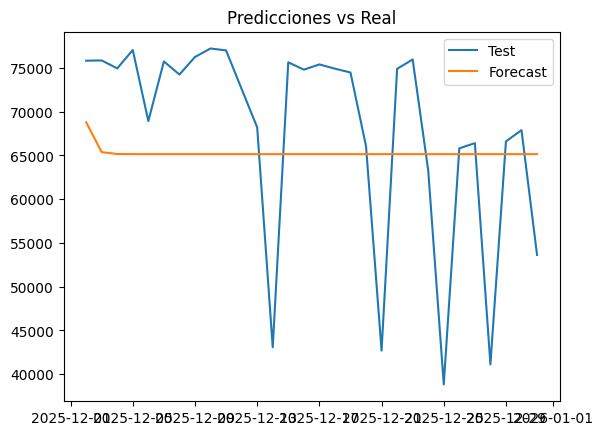

In [27]:
plt.plot(test['y'], label='Test')
plt.plot(predictions_arima, label='Forecast')

# Title and legend
plt.title(f"Predicciones vs Real")
plt.legend()
plt.show()

# SARIMA

In [90]:
model_sarima = auto_arima(train['y'],
                   seasonal = True,
                    m=7)
model_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 2891
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 7)   Log Likelihood              -31340.251
Date:                            Fri, 15 May 2026   AIC                          62688.501
Time:                                    15:18:11   BIC                          62712.378
Sample:                                01-02-2018   HQIC                         62697.106
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8285      0.008   -108.551      0.000      -0.844      -0.814
ar.S.L7        0.3483      0.011     32.890      0.000       0.328       0.369
ar.S.L14       0.3154      0.011     27.600      0.000       0.293       0.338
sigma2      1.536e+08   1.56e-11   9.86e+18      0.000    1.54e+08    1.54e+08
===================================================================================
Ljung-Box (L1) (Q):                  71.68   Jarque-Bera (JB):              7896.44
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.74   Skew:                            -1.33
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.65
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.24e+33. Standard errors may be unstable.
"""

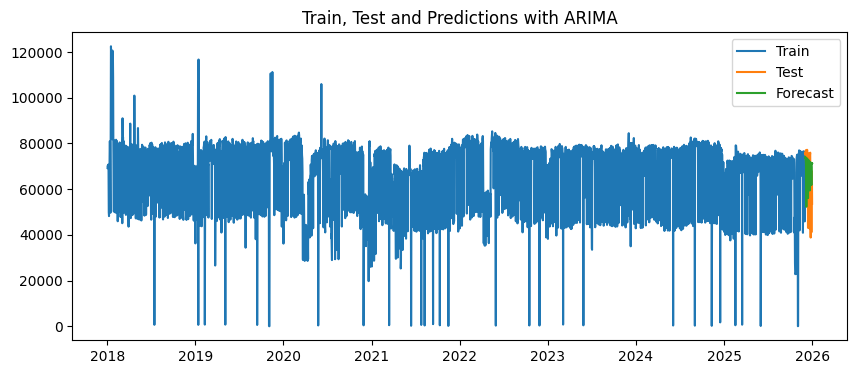

The MAE is 6584.95
The RMSE is 10163.03
The MAPE is 12.36 %


In [91]:
# Use the fitted ARIMA model to forecast future values.
# set the number of periods to forecast to the length of 'test'
predictions_sarima = model_sarima.predict(n_periods = len(test))

predictions_sarima = pd.Series(
    predictions_arima,
    index=test.index
)

# Model assessment
model_assessment(
    train['y'],
    test['y'],
    predictions_sarima,
    "ARIMA"
)

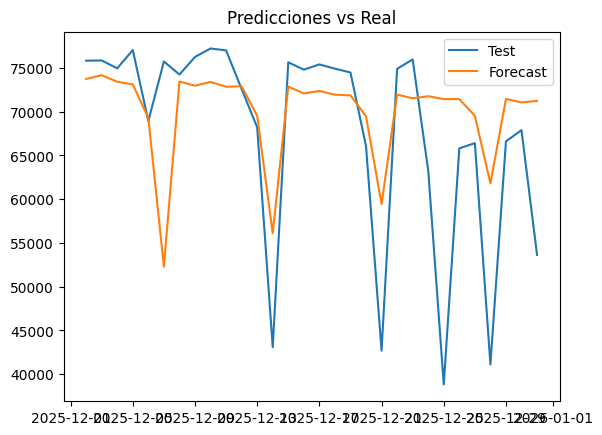

In [92]:
plt.plot(test['y'], label='Test')
plt.plot(predictions_sarima, label='Forecast')

# Title and legend
plt.title(f"Predicciones vs Real")
plt.legend()
plt.show()

- `MAE` - the average of the absolute differences between predicted and actual values.
- `RMSE` - the square root of the average of squared differences between prediction and actual observation.
It gives a relatively high weight to large errors, making it sensitive to outliers.
- `MAPE` - the size of the error in percentage terms. the average of the absolute percent errors of forecasts, which helps to understand the accuracy in terms of percentage.

# SARIMAX

In [58]:
# Loading the exogenus data

df_exo = pd.read_csv("features_mes_completo.csv")

df_exo["Fecha"] = pd.to_datetime(df_exo["Fecha"])

df_exo = df_exo.set_index("Fecha")

# just interest in the first 12 columns
df_exo = df_exo.iloc[:, :12]

In [60]:
# Change the time Series variable name
df = df_exo.rename(columns = {'Consumo': 'y'}).copy()

cols = [col for col in df.columns if col != 'y']
df = df[cols + ['y']]

In [66]:
import pandas as pd
from pmdarima import auto_arima

# 1. Convertir los True/False en 1/0 para que statsmodels los entienda
df_numeric = df.astype({
    'es_fin_semana': int,
    'es_festivo': int,
    'dia_antes_festivo': int,
    'dia_despues_festivo': int,
    'semana_navidad': int,
    'covid_cuarentena': int,
    'es_mantenimiento': int
})
test_days = 30

# 3. Separar en Train y Test (Asumiendo que 'Consumo' es tu variable 'y')
df_train = df_numeric.iloc[:-test_days]
df_test = df_numeric.iloc[-test_days:]

# Tu variable objetivo es 'y'
y_train = df_train['y']
X_train = df_train.drop(columns=['y'])

y_test = df_test['y']
X_test = df_test.drop(columns=['y'])

In [69]:
# auto_arima() from pmdarima - used to automatically select the optimal parameters for an ARIMA model based on the provided time series data.
# m = The number of periods in each season.
# X =  exogenous variables.
# Fit the Auto-ARIMA model
model_sarimax = auto_arima(
    y=y_train,       # Your training target variable
    X=X_train,       # Your training exogenous features
    m=7,             # Weekly seasonality
    seasonal=True
)

In [73]:
# Use the fitted SARIMAX model to forecast future values.
# set the number of periods to forecast to the length of 'test'
# X - representing the exogenous variables for forecasting
predictions_sarimax = model_sarimax.predict(n_periods = len(y_test),
                                            X = X_test)

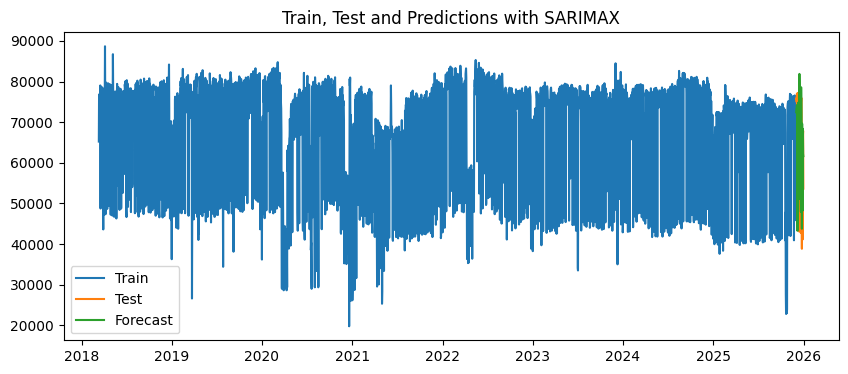

The MAE is 4676.78
The RMSE is 7914.68
The MAPE is 7.36 %


In [85]:
# Model assessment
model_assessment(y_train['2018':], y_test, predictions_sarimax, "SARIMAX")

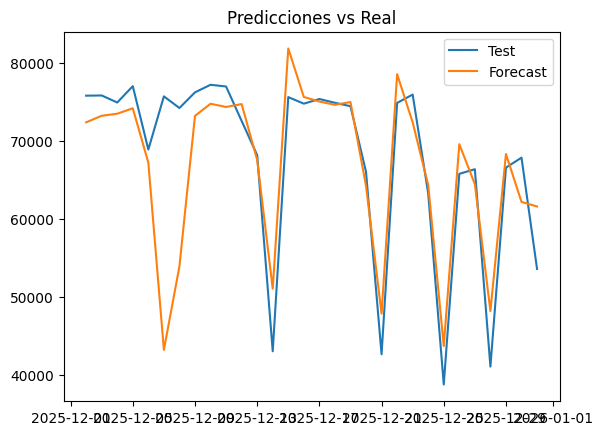

In [93]:
plt.plot(y_test, label='Test')
plt.plot(predictions_sarimax, label='Forecast')

# Title and legend
plt.title(f"Predicciones vs Real")
plt.legend()
plt.show()

# Cross Validation

In [ ]:
# Define the model to do CV
# order = ([p] autoregressive order, [d] differencing order, [q] moving average order)
# seasonal_order = ([P] seasonal autoregressive order, [D] seasonal differencing order, [Q] seasonal moving average order, [m] number of periods per season)
model_cv = ARIMA(order = (2, 1, 2), seasonal_order = (2, 0, 2, 7))

In [ ]:
# Define the rules for Rolling Forecast Cross-Validation (RollingForecastCV).
cv = model_selection.RollingForecastCV(h = 30, # forecast horizon
                                       step = 15, # moves the validation window by n time steps each iteration
                                       initial = df.shape[0] - 180) # starting point for the first training set

In [ ]:
# Perform cross-validation scoring using specified inputs.
cv_score = model_selection.cross_val_score(model_cv,
                                           y=df['y'],  # Target variable 'y'
                                           X=df.iloc[:, 1:3],  # Explanatory variables from columns 1 and 2
                                           scoring='mean_squared_error',  # Evaluation metric: Mean Squared Error
                                           cv=cv,  # Cross-validation strategy
                                           verbose=1,  # Verbosity level
                                           error_score=10000000000000000000000  # Value to assign if fitting error occurs
                                           )


In [ ]:
# Calculate Root Mean Squared Error (RMSE) using cross-validated scores.
rmse = np.sqrt(np.average(cv_score))
print(f"The RMSE is {int(rmse)}")

# Parameter Tuning

In [ ]:
# Defining the parameters
param_grid = {'p': [1,2,3],
              'd': [0,1],
              'q': [1,2,3],
              'P': [1,2],
              'D': [0],
              'Q': [1,2]}
grid = ParameterGrid(param_grid)
len(list(grid))

In [ ]:
# Initialize an empty list to store RMSE values for each parameter set
rmse_list = []

# Iterate over each set of parameters in the grid
for params in grid:

  # Build an ARIMA model with the current set of parameters
  model = ARIMA(order=(params['p'], params['d'], params['q']),
                seasonal_order=(params['P'], params['D'], params['Q'], 7))

  # Define the Rolling Forecast Cross-Validation strategy
  cv = model_selection.RollingForecastCV(h=30,
                                         step=15,
                                         initial=df.shape[0] - 180)

  # Perform cross-validation scoring with the ARIMA model
  cv_score = model_selection.cross_val_score(model,
                                             y=df['y'],  # Target variable 'y'
                                             X=df.iloc[:, 1:3],  # Explanatory variables from columns 1 and 2
                                             scoring='mean_squared_error',  # Evaluation metric: Mean Squared Error
                                             cv=cv,  # Cross-validation strategy
                                             verbose=1,  # Verbosity level
                                             error_score=10000000000000000000000  # Value to assign if fitting error occurs
                                             )

  # Calculate RMSE and store the error
  rmse = np.sqrt(np.average(cv_score))
  rmse_list.append(rmse)


In [ ]:
# Create a DataFrame to store the tuning results with parameters and corresponding RMSE values
tuning_results = pd.DataFrame(grid)

# Add the RMSE values calculated during parameter tuning to the DataFrame
tuning_results['rmse'] = rmse_list

tuning_results

In [ ]:
# Save the best parameters
best_params = tuning_results[tuning_results['rmse'] == tuning_results['rmse'].min()].transpose()
best_params

# Predicting the future

In [ ]:
# target variable - daily revenue
y = df['y']
# exogenous variables
X = df.iloc[:,1:3]

In [ ]:
# Fetch the best parameters
p = int(best_params.loc['p'])
d = int(best_params.loc['d'])
q = int(best_params.loc['q'])
P = int(best_params.loc['P'])
D = int(best_params.loc['D'])
Q = int(best_params.loc['Q'])

In [ ]:
# Loading the future regressors data and set the date as index
df_future = pd.read_csv("future_regressors.csv",
                 index_col = "date",
                 parse_dates = True,
                 dayfirst = True)
df_future.head()

In [ ]:
# multiply all regressor columns by 100
# to make it as percentage values
X_future = df_future.iloc[:,1:3] * 100

In [ ]:
# Tuned Sarimax Model with the best parameters
tuned_model = ARIMA(order = (p, d, q),
                    seasonal_order = (P, D, Q, 7))
# fit the model, add exogenous variables as X
tuned_model.fit(y, X = X)

In [ ]:
# Forecasting
# set the number of periods to forecast to the length of 'X_future'
# add future exogenous variables as X
predictions = tuned_model.predict(n_periods = len(X_future),
                                  X = X_future)

In [ ]:
# Data Visualization
plot_future(y['2022':], predictions, "SARIMAX")

Left to do: Feature Engineering